# SpatioEv Tutorial 03: SVM Phenotype Probabilities

Train an SVM on Scimap-derived phenotype labels using expression plus morphology features. Artifact cells are removed before feature construction. Unknown cells stay in the non-artifact modeling population for prediction, but are excluded from train/test labels.

## Setup And Full Data

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.svm import SVC

import spatioev as sv

ROOT = Path.cwd()
if not (ROOT / "spatioev").exists():
    for candidate in ROOT.parents:
        if (candidate / "spatioev").exists():
            ROOT = candidate
            break

DATA_DIR = ROOT / "data"
BACKGROUND_DIR = ROOT / "background"
RESULT_DIR = ROOT / "results"
RESULT_DIR.mkdir(exist_ok=True)

EXP1_H5AD = DATA_DIR / "exp_1" / "exp_1.h5ad"
SCIMAP_ANNOTATION_PATH = RESULT_DIR / "scimap_prior_knowledge_annotations.csv"
SVM_RESULT_PATH = RESULT_DIR / "svm_phenotyping_results.csv"
SVM_PROBABILITY_PATH = RESULT_DIR / "svm_phenotyping_probabilities.csv"
SVM_REPORT_PATH = RESULT_DIR / "svm_phenotyping_test_report.csv"
SVM_CONFUSION_PATH = RESULT_DIR / "svm_phenotyping_test_confusion_matrix.csv"

ORIGINAL_IMAGE_PATH = BACKGROUND_DIR / "OnTIMEr18_n_a_backsub.ome.tif"
if not ORIGINAL_IMAGE_PATH.exists():
    ORIGINAL_IMAGE_PATH = None

TARGET_KEY = "scimap_phenotype"
EXCLUDE_LABELS = ["artifact"]
PREDICT_ONLY_LABELS = ["Unknown"]
TEST_SIZE = 0.25
RANDOM_STATE = 42
PROBABILITY_THRESHOLD = 0.60
UNKNOWN_REFINEMENT_PROBABILITY_THRESHOLD = 0.60
# Known-label reassignment is intentionally less stringent for spillover correction.
# Set DISAGREEMENT_MARGIN_THRESHOLD > 0 to require a stronger gap over the original label.
DISAGREEMENT_REFINEMENT_PROBABILITY_THRESHOLD = 0.2
DISAGREEMENT_MARGIN_THRESHOLD = 0.00
APPLY_DISAGREEMENT_REFINEMENT = True
SVM_KERNEL = "rbf"
SVM_C = 1.0
SVM_GAMMA = "scale"

# Feature-group weights are applied after within-group imputation and z-scoring.
EXPRESSION_WEIGHT = 1.0
MORPHOLOGY_WEIGHT = 0.4

MORPH_FEATURES = [
    "area",
    "convex_area",
    "perimeter",
    "major_axis_length",
    "minor_axis_length",
    "feret_diameter_max",
    "equivalent_diameter",
    "num_concavities",
    "centroid_dif",
    "eccentricity",
    "solidity",
    "major_minor_axis_ratio",
    "perim_square_over_area",
    "major_axis_equiv_diam_ratio",
    "convex_hull_resid",
    "circularity",
    "fractal_dimension",
    "boundary_irregularity",
    "nc_ratio",
]

LOG1P_MORPH_FEATURES = [
    "area",
    "convex_area",
    "perimeter",
    "major_axis_length",
    "minor_axis_length",
    "feret_diameter_max",
    "equivalent_diameter",
    "num_concavities",
    "centroid_dif",
]


def dense_matrix(x):
    return x.toarray() if sparse.issparse(x) else np.asarray(x)


def load_full_adata():
    if not EXP1_H5AD.exists():
        raise FileNotFoundError(f"Expected AnnData at {EXP1_H5AD}.")
    adata = sv.io.load_h5ad(EXP1_H5AD)
    adata = sv.pp.validate_spatial_coordinates(
        adata,
        x_key="X_centroid",
        y_key="Y_centroid",
        image_key="imageid",
    )
    adata.obs["imageid"] = adata.obs["imageid"].astype(str)
    return adata


def load_scimap_target(adata, path=SCIMAP_ANNOTATION_PATH, target_key=TARGET_KEY):
    if not path.exists():
        raise FileNotFoundError(
            f"Expected Scimap annotations at {path}. Run the Scimap phenotyping notebook first."
        )

    annotations = pd.read_csv(path, index_col=0)
    annotations.index = annotations.index.astype(str)
    if annotations.index.has_duplicates:
        raise ValueError(f"{path} contains duplicate cell IDs.")
    if target_key not in annotations.columns:
        raise ValueError(f"{path} must contain {target_key!r}.")

    obs_names = pd.Index(adata.obs_names.astype(str))
    missing_cells = obs_names.difference(annotations.index)
    if len(missing_cells):
        preview = ", ".join(missing_cells[:5])
        raise ValueError(f"{path} is missing {len(missing_cells)} AnnData cells, e.g. {preview}.")

    target = annotations.loc[obs_names, target_key]
    target = target.where(target.notna(), pd.NA).astype("string").str.strip()
    target = target.replace({"": pd.NA, "nan": pd.NA, "None": pd.NA, "NA": pd.NA})
    adata.obs[target_key] = target.to_numpy()
    return annotations.loc[obs_names]


def build_feature_table(adata, markers, morph_features):
    missing_morph = [feature for feature in morph_features if feature not in adata.obs.columns]
    if missing_morph:
        raise ValueError(f"Missing morphology features in adata.obs: {missing_morph}")

    expression = dense_matrix(adata[:, markers].X)
    expression = pd.DataFrame(
        expression,
        index=adata.obs_names,
        columns=[f"expr:{marker}" for marker in markers],
    )

    morphology = adata.obs[morph_features].apply(pd.to_numeric, errors="coerce").copy()
    for feature in LOG1P_MORPH_FEATURES:
        if feature in morphology.columns:
            morphology[feature] = np.log1p(morphology[feature].clip(lower=0))
    morphology.columns = [f"morph:{feature}" for feature in morphology.columns]

    return pd.concat([expression, morphology], axis=1)


def feature_weight_transformer(weight):
    return FunctionTransformer(
        lambda x: x * weight,
        feature_names_out="one-to-one",
    )


def show_counts(series, label, n=30):
    counts = series.astype("string").value_counts(dropna=False).rename_axis(label).to_frame("n_cells")
    display(counts.head(n))
    return None


def safe_spatial_scatter(adata, color, title=None, size=2):
    required = {"X_centroid", "Y_centroid", "imageid"}
    if not required.issubset(adata.obs.columns):
        print(f"Skipping spatial plot: missing columns {sorted(required - set(adata.obs.columns))}.")
        return None
    if color not in adata.obs.columns and color not in adata.var_names:
        print(f"Skipping spatial plot: {color!r} is not available.")
        return None
    sv.pl.spatial_scatter_plot(
        adata,
        colorBy=color,
        x_coordinate="X_centroid",
        y_coordinate="Y_centroid",
        imageid="imageid",
        s=size,
        figsize=(5, 5),
    )
    if title:
        plt.suptitle(title)
    plt.show()
    plt.close("all")
    return None


def review_on_original_image(adata, label, image_path=ORIGINAL_IMAGE_PATH, run=False):
    if not run:
        print("Set run=True in this cell to open the original-image overlay viewer.")
        return None
    if image_path is None or not Path(image_path).exists():
        print("Original image path is not available; using the static spatial scatter instead.")
        return safe_spatial_scatter(adata, label, f"{label} spatial review")
    try:
        sv.pl.inspect_clusters(adata, image_path=str(image_path), label=label, block=True)
    except Exception as exc:
        print(f"Image overlay viewer could not open: {exc}")
        return safe_spatial_scatter(adata, label, f"{label} spatial review")
    return None


adata = load_full_adata()
expression_markers = list(map(str, adata.var_names))
print(f"SpatioEv {sv.__version__}")
print(f"Loaded {EXP1_H5AD.relative_to(ROOT)}: {adata.n_obs:,} cells x {adata.n_vars:,} markers")
print("Expression markers:", expression_markers)
print("Original image:", ORIGINAL_IMAGE_PATH if ORIGINAL_IMAGE_PATH else "not found")


SpatioEv 0.1.0
Loaded data/exp_1/exp_1.h5ad: 51,932 cells x 25 markers
Expression markers: ['DNA_1', 'IGFBP5', 'COL4A1', 'CD146', 'RS6', 'CD31', 'Vimentin', 'CD68', 'CD19', 'PCK', 'CD3', 'NaKATPase', 'COL1A1', 'CD90', 'PDPN', 'CK19', 'Tenascin', 'COL6A1', 'SMA', 'FN', 'CD45', 'HLADR', 'CD11c', 'CD4', 'CD14']
Original image: /Users/shihongwu/SpatioEv/background/OnTIMEr18_n_a_backsub.ome.tif


## Load Scimap Target And Remove Artifacts

In [2]:
scimap_annotations = load_scimap_target(adata)
target_full = adata.obs[TARGET_KEY].astype("string")
exclude_labels = {label.casefold() for label in EXCLUDE_LABELS}
predict_only_labels = {label.casefold() for label in PREDICT_ONLY_LABELS}
artifact_mask = target_full.str.casefold().isin(exclude_labels).fillna(False)
missing_target_mask = target_full.isna()
model_mask = (~artifact_mask) & (~missing_target_mask)

adata_model = adata[model_mask.to_numpy()].copy()
model_target = adata_model.obs[TARGET_KEY].astype("string")
predict_only_mask = model_target.str.casefold().isin(predict_only_labels).fillna(False)

print(f"Target annotations: {SCIMAP_ANNOTATION_PATH.relative_to(ROOT)}")
print(f"Full input cells: {adata.n_obs:,}")
print(f"Removed artifacts: {int(artifact_mask.sum()):,}")
print(f"Removed missing targets: {int(missing_target_mask.sum()):,}")
print(f"Modeling population: {adata_model.n_obs:,} non-artifact cells")
print(f"Prediction-only cells: {int(predict_only_mask.sum()):,}")

print("Full target labels")
show_counts(target_full, TARGET_KEY)

print("Modeling target labels")
show_counts(model_target, TARGET_KEY)


Target annotations: results/scimap_prior_knowledge_annotations.csv
Full input cells: 51,932
Removed artifacts: 3,824
Removed missing targets: 0
Modeling population: 48,108 non-artifact cells
Prediction-only cells: 9,318
Full target labels


,n_cells
scimap_phenotype,
tumour,24946
Unknown,9318
myCAFs,3957
artifact,3824
endothelial,3048
CD4 T cells,2275
Monocytes,1703
Macrophages,932
T cells,924


Modeling target labels


,n_cells
scimap_phenotype,
tumour,24946
Unknown,9318
myCAFs,3957
endothelial,3048
CD4 T cells,2275
Monocytes,1703
Macrophages,932
T cells,924
PDPN+ CAFs,595


## Build Non-Artifact Expression And Morphology Features

In [3]:
feature_table = build_feature_table(adata_model, expression_markers, MORPH_FEATURES)
expression_feature_cols = [column for column in feature_table.columns if column.startswith("expr:")]
morphology_feature_cols = [column for column in feature_table.columns if column.startswith("morph:")]

feature_summary = (
    pd.DataFrame(
        {
            "feature_group": [column.split(":", 1)[0] for column in feature_table.columns],
            "weight": [
                EXPRESSION_WEIGHT if column.startswith("expr:") else MORPHOLOGY_WEIGHT
                for column in feature_table.columns
            ],
        }
    )
    .groupby("feature_group", observed=True)
    .agg(n_features=("feature_group", "size"), weight=("weight", "first"))
)

print(f"Feature matrix: {feature_table.shape[0]:,} non-artifact cells x {feature_table.shape[1]:,} features")
display(feature_summary)


Feature matrix: 48,108 non-artifact cells x 44 features


,n_features,weight
feature_group,,
expr,25,1.0
morph,19,0.4


## Split Labelled Non-Artifact Cells Into Train And Test Sets

In [4]:
target = adata_model.obs[TARGET_KEY].astype("string")
predict_only_mask = target.str.casefold().isin(predict_only_labels).fillna(False)
trainable_mask = ~predict_only_mask
trainable_target = target[trainable_mask]

trainable_counts = trainable_target.value_counts()
if len(trainable_counts) < 2:
    raise ValueError("SVM training requires at least two non-artifact, non-Unknown phenotype classes.")
if (trainable_counts < 2).any():
    too_small = trainable_counts[trainable_counts < 2]
    raise ValueError(f"Every class needs at least two cells for stratified splitting: {too_small.to_dict()}")

train_test_names = adata_model.obs_names[trainable_mask.to_numpy()]
train_names, test_names = train_test_split(
    train_test_names,
    test_size=TEST_SIZE,
    stratify=target.loc[train_test_names],
    random_state=RANDOM_STATE,
)

adata_model.obs["svm_training_status"] = "predict_only"
adata_model.obs.loc[train_names, "svm_training_status"] = "train"
adata_model.obs.loc[test_names, "svm_training_status"] = "test"

print(f"Training cells: {len(train_names):,}")
print(f"Test cells: {len(test_names):,}")
print(f"Prediction-only cells: {int(predict_only_mask.sum()):,}")
show_counts(adata_model.obs["svm_training_status"], "svm_training_status")
show_counts(trainable_target, TARGET_KEY)


Training cells: 29,092
Test cells: 9,698
Prediction-only cells: 9,318


,n_cells
svm_training_status,
train,29092
test,9698
predict_only,9318


,n_cells
scimap_phenotype,
tumour,24946
myCAFs,3957
endothelial,3048
CD4 T cells,2275
Monocytes,1703
Macrophages,932
T cells,924
PDPN+ CAFs,595
Dendritic cells,285


## Train SVM And Evaluate Held-Out Test Cells

This uses an RBF SVM with probability estimates. It is expected to run more slowly than a linear SVM, but can capture nonlinear boundaries between phenotypes.

In [5]:
X_train = feature_table.loc[train_names]
y_train = target.loc[train_names]
X_test = feature_table.loc[test_names]
y_test = target.loc[test_names]

feature_preprocessor = ColumnTransformer(
    transformers=[
        (
            "expression",
            Pipeline(
                steps=[
                    ("impute", SimpleImputer(strategy="median")),
                    ("scale", StandardScaler()),
                    ("weight", feature_weight_transformer(EXPRESSION_WEIGHT)),
                ]
            ),
            expression_feature_cols,
        ),
        (
            "morphology",
            Pipeline(
                steps=[
                    ("impute", SimpleImputer(strategy="median")),
                    ("scale", StandardScaler()),
                    ("weight", feature_weight_transformer(MORPHOLOGY_WEIGHT)),
                ]
            ),
            morphology_feature_cols,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

svm_model = Pipeline(
    steps=[
        ("features", feature_preprocessor),
        (
            "svm",
            SVC(
                kernel=SVM_KERNEL,
                C=SVM_C,
                gamma=SVM_GAMMA,
                probability=True,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

print(
    f"Training {SVM_KERNEL!r} SVM on {len(train_names):,} cells, "
    f"{feature_table.shape[1]:,} features, {target.loc[train_names].nunique()} classes."
)
svm_model.fit(X_train, y_train)
svm_classes = svm_model.named_steps["svm"].classes_

test_prediction = pd.Series(svm_model.predict(X_test), index=test_names, name="svm_prediction")
report_df = pd.DataFrame(
    classification_report(y_test, test_prediction, output_dict=True, zero_division=0)
).transpose()
confusion_df = pd.DataFrame(
    confusion_matrix(y_test, test_prediction, labels=svm_classes),
    index=pd.Index(svm_classes, name="true"),
    columns=pd.Index(svm_classes, name="predicted"),
)

display(report_df.round(3))
display(confusion_df)


Training 'rbf' SVM on 29,092 cells, 44 features, 10 classes.


,precision,recall,f1-score,support
CD4 T cells,0.878,0.935,0.906,569.000
CD90+ CAFs,0.528,0.613,0.567,31.000
Dendritic cells,0.725,0.704,0.714,71.000
Macrophages,0.897,0.974,0.934,233.000
Monocytes,0.875,0.934,0.904,426.000
PDPN+ CAFs,0.641,0.886,0.744,149.000
T cells,0.730,0.900,0.806,231.000
endothelial,0.908,0.963,0.935,762.000
myCAFs,0.958,0.913,0.935,989.000
tumour,0.997,0.965,0.980,6237.000


predicted,CD4 T cells,CD90+ CAFs,Dendritic cells,Macrophages,Monocytes,PDPN+ CAFs,T cells,endothelial,myCAFs,tumour
true,,,,,,,,,,
CD4 T cells,532,0,1,4,6,2,14,7,1,2
CD90+ CAFs,0,19,0,0,0,5,0,0,6,1
Dendritic cells,3,0,50,5,5,1,1,3,3,0
Macrophages,0,0,1,227,4,0,0,0,0,1
Monocytes,5,0,5,11,398,0,2,1,0,4
PDPN+ CAFs,2,3,2,0,1,132,1,1,5,2
T cells,12,0,0,1,1,1,208,3,2,3
endothelial,4,0,1,0,4,3,6,734,7,3
myCAFs,9,12,9,0,1,31,9,11,903,4


## Predict Probabilities For All Non-Artifact Cells

The fitted model is applied to every non-artifact cell, including `Unknown` cells that were held out from training and testing.

In [6]:
full_prediction = pd.Series(
    svm_model.predict(feature_table),
    index=adata_model.obs_names,
    name="svm_prediction",
)
full_probability = pd.DataFrame(
    svm_model.predict_proba(feature_table),
    index=adata_model.obs_names,
    columns=[f"svm_prob_{label}" for label in svm_classes],
)

svm_adata = adata_model.copy()
svm_adata.obs["svm_prediction"] = full_prediction.astype(str)
for column in full_probability.columns:
    svm_adata.obs[column] = full_probability[column].to_numpy()

prob_cols = list(full_probability.columns)
svm_adata.obs["svm_max_probability"] = full_probability.max(axis=1).to_numpy()
svm_adata.obs["svm_prediction_confident"] = np.where(
    svm_adata.obs["svm_max_probability"] >= PROBABILITY_THRESHOLD,
    svm_adata.obs["svm_prediction"].astype(str),
    "uncertain",
)

show_counts(svm_adata.obs["svm_prediction"], "svm_prediction")
show_counts(svm_adata.obs["svm_prediction_confident"], "svm_prediction_confident")
display(svm_adata.obs[[TARGET_KEY, "svm_training_status", "svm_prediction", "svm_max_probability", "svm_prediction_confident"]].head())


,n_cells
svm_prediction,
tumour,25060
endothelial,4845
myCAFs,4819
Monocytes,3561
T cells,2742
CD4 T cells,2742
PDPN+ CAFs,1517
Macrophages,1379
Dendritic cells,1162


,n_cells
svm_prediction_confident,
tumour,25058
myCAFs,4670
endothelial,4327
uncertain,3629
Monocytes,2894
CD4 T cells,2434
T cells,1840
Macrophages,1171
PDPN+ CAFs,1112


,scimap_phenotype,svm_training_status,svm_prediction,svm_max_probability,svm_prediction_confident
exp_109,tumour,train,tumour,0.984310,tumour
exp_118,tumour,train,tumour,0.985485,tumour
exp_129,tumour,train,tumour,0.981459,tumour
exp_145,tumour,train,T cells,0.588420,uncertain
exp_154,tumour,train,tumour,0.973304,tumour


## Visualize Predictions And Refine Phenotypes

Use the SVM probabilities to inspect model confidence and refine Scimap phenotype labels. Confident `Unknown` cells are replaced automatically. Known labels are also updated when the SVM's best phenotype differs from the original label, has sufficient probability, and is at least as probable as the original phenotype. This less stringent rule is useful for correcting spillover-driven labels, such as immune cells inside tumour nests that were originally called tumour.

In [7]:
probability_by_class = full_probability.copy()
probability_by_class.columns = [column.removeprefix("svm_prob_") for column in probability_by_class.columns]

original_labels = svm_adata.obs[TARGET_KEY].astype("string")
predicted_labels = svm_adata.obs["svm_prediction"].astype("string")
known_model_classes = set(probability_by_class.columns.astype(str))

original_probability = pd.Series(np.nan, index=svm_adata.obs_names, dtype=float)
for phenotype in probability_by_class.columns:
    mask = original_labels.eq(phenotype).fillna(False)
    original_probability.loc[mask] = probability_by_class.loc[mask, phenotype]

svm_adata.obs["svm_original_probability"] = original_probability.to_numpy()
svm_adata.obs["svm_probability_margin_over_original"] = (
    svm_adata.obs["svm_max_probability"].astype(float)
    - svm_adata.obs["svm_original_probability"].fillna(0.0).astype(float)
)

refine_source_labels = {label.casefold() for label in PREDICT_ONLY_LABELS}
refine_source_mask = original_labels.str.casefold().isin(refine_source_labels).fillna(False)
unknown_refine_mask = refine_source_mask & (
    svm_adata.obs["svm_max_probability"] >= UNKNOWN_REFINEMENT_PROBABILITY_THRESHOLD
)

known_original_mask = original_labels.isin(known_model_classes).fillna(False)
disagreement_mask = (
    known_original_mask
    & ~refine_source_mask
    & predicted_labels.notna()
    & original_labels.ne(predicted_labels).fillna(False)
)
disagreement_candidate_mask = (
    disagreement_mask
    & (svm_adata.obs["svm_max_probability"] >= DISAGREEMENT_REFINEMENT_PROBABILITY_THRESHOLD)
    & (svm_adata.obs["svm_probability_margin_over_original"] >= DISAGREEMENT_MARGIN_THRESHOLD)
)
disagreement_refine_mask = disagreement_candidate_mask & APPLY_DISAGREEMENT_REFINEMENT

svm_adata.obs["svm_refined_phenotype"] = original_labels.astype(str)
svm_adata.obs.loc[unknown_refine_mask, "svm_refined_phenotype"] = svm_adata.obs.loc[
    unknown_refine_mask,
    "svm_prediction",
].astype(str)
svm_adata.obs.loc[disagreement_refine_mask, "svm_refined_phenotype"] = svm_adata.obs.loc[
    disagreement_refine_mask,
    "svm_prediction",
].astype(str)

svm_adata.obs["svm_refinement_status"] = np.select(
    [
        unknown_refine_mask.to_numpy(),
        disagreement_refine_mask.to_numpy(),
        disagreement_candidate_mask.to_numpy(),
        refine_source_mask.to_numpy(),
        disagreement_mask.to_numpy(),
    ],
    [
        "refined_unknown_from_prediction",
        "refined_disagreement_from_prediction",
        "review_disagreement_high_confidence",
        "kept_prediction_only_low_confidence",
        "kept_original_label_model_disagrees",
    ],
    default="kept_original_label",
)

print(f"Unknown refinement threshold: {UNKNOWN_REFINEMENT_PROBABILITY_THRESHOLD:.2f}")
print(
    "Known-label disagreement rule: "
    f"P(predicted) >= {DISAGREEMENT_REFINEMENT_PROBABILITY_THRESHOLD:.2f}, "
    f"P(predicted) - P(original) >= {DISAGREEMENT_MARGIN_THRESHOLD:.2f}, "
    f"apply={APPLY_DISAGREEMENT_REFINEMENT}"
)
show_counts(svm_adata.obs["svm_refinement_status"], "svm_refinement_status")
show_counts(svm_adata.obs["svm_refined_phenotype"], "svm_refined_phenotype")

prediction_only = svm_adata.obs["svm_training_status"].eq("predict_only")
if prediction_only.any():
    print("Prediction-only cells")
    display(
        svm_adata.obs.loc[
            prediction_only,
            [
                TARGET_KEY,
                "svm_prediction",
                "svm_max_probability",
                "svm_refined_phenotype",
                "svm_refinement_status",
            ],
        ]
        .sort_values("svm_max_probability", ascending=False)
        .head(20)
    )

if disagreement_candidate_mask.any():
    print("High-confidence known-label disagreements to review")
    display(
        svm_adata.obs.loc[
            disagreement_candidate_mask,
            [
                TARGET_KEY,
                "svm_prediction",
                "svm_original_probability",
                "svm_max_probability",
                "svm_probability_margin_over_original",
                "svm_refined_phenotype",
                "svm_refinement_status",
            ],
        ]
        .sort_values("svm_probability_margin_over_original", ascending=False)
        .head(30)
    )
else:
    print("No high-confidence known-label disagreements met the review threshold.")


Unknown refinement threshold: 0.60
Known-label disagreement rule: P(predicted) >= 0.20, P(predicted) - P(original) >= 0.00, apply=True


,n_cells
svm_refinement_status,
kept_original_label,37364
refined_unknown_from_prediction,6467
kept_prediction_only_low_confidence,2851
refined_disagreement_from_prediction,1426


,n_cells
svm_refined_phenotype,
tumour,25058
myCAFs,4728
endothelial,4433
Monocytes,2960
Unknown,2851
CD4 T cells,2597
T cells,2017
PDPN+ CAFs,1220
Macrophages,1218


Prediction-only cells


,scimap_phenotype,svm_prediction,svm_max_probability,svm_refined_phenotype,svm_refinement_status
exp_31152,Unknown,tumour,1.000000,tumour,refined_unknown_from_prediction
exp_31069,Unknown,tumour,1.000000,tumour,refined_unknown_from_prediction
exp_16167,Unknown,tumour,1.000000,tumour,refined_unknown_from_prediction
exp_34027,Unknown,tumour,1.000000,tumour,refined_unknown_from_prediction
exp_38181,Unknown,tumour,1.000000,tumour,refined_unknown_from_prediction
exp_33963,Unknown,tumour,1.000000,tumour,refined_unknown_from_prediction
exp_41006,Unknown,tumour,1.000000,tumour,refined_unknown_from_prediction
exp_20490,Unknown,tumour,0.999999,tumour,refined_unknown_from_prediction
exp_20085,Unknown,tumour,0.999999,tumour,refined_unknown_from_prediction
exp_30328,Unknown,tumour,0.999999,tumour,refined_unknown_from_prediction


High-confidence known-label disagreements to review


,scimap_phenotype,svm_prediction,svm_original_probability,svm_max_probability,svm_probability_margin_over_original,svm_refined_phenotype,svm_refinement_status
exp_31081,endothelial,myCAFs,0.002150,0.996365,0.994214,myCAFs,refined_disagreement_from_prediction
exp_42850,tumour,CD4 T cells,0.002330,0.994541,0.992211,CD4 T cells,refined_disagreement_from_prediction
exp_36432,tumour,endothelial,0.004101,0.995850,0.991749,endothelial,refined_disagreement_from_prediction
exp_49270,Monocytes,tumour,0.001360,0.988102,0.986743,tumour,refined_disagreement_from_prediction
exp_8409,Monocytes,Macrophages,0.006768,0.993111,0.986343,Macrophages,refined_disagreement_from_prediction
exp_25983,endothelial,CD4 T cells,0.006943,0.992555,0.985613,CD4 T cells,refined_disagreement_from_prediction
exp_7271,tumour,endothelial,0.007383,0.992472,0.985089,endothelial,refined_disagreement_from_prediction
exp_45701,tumour,PDPN+ CAFs,0.006136,0.990895,0.984759,PDPN+ CAFs,refined_disagreement_from_prediction
exp_43136,tumour,CD4 T cells,0.008468,0.990599,0.982132,CD4 T cells,refined_disagreement_from_prediction
exp_7905,Dendritic cells,myCAFs,0.007109,0.988049,0.980940,myCAFs,refined_disagreement_from_prediction


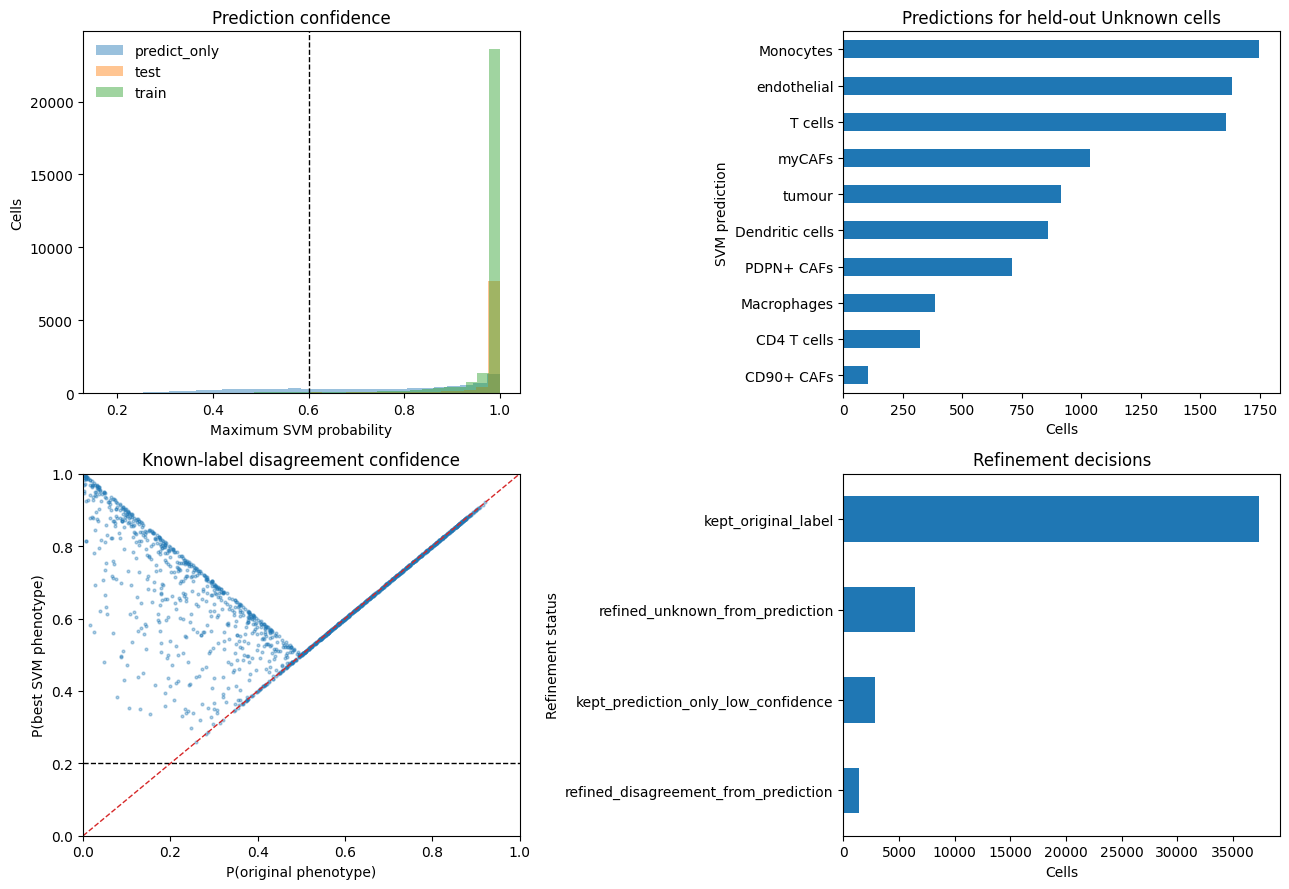

svm_prediction,CD4 T cells,CD90+ CAFs,Dendritic cells,Macrophages,Monocytes,PDPN+ CAFs,T cells,endothelial,myCAFs,tumour
scimap_phenotype,,,,,,,,,,
CD4 T cells,0.935,0.000,0.002,0.007,0.011,0.004,0.025,0.012,0.002,0.004
CD90+ CAFs,0.000,0.613,0.000,0.000,0.000,0.161,0.000,0.000,0.194,0.032
Dendritic cells,0.042,0.000,0.704,0.070,0.070,0.014,0.014,0.042,0.042,0.000
Macrophages,0.000,0.000,0.004,0.974,0.017,0.000,0.000,0.000,0.000,0.004
Monocytes,0.012,0.000,0.012,0.026,0.934,0.000,0.005,0.002,0.000,0.009
PDPN+ CAFs,0.013,0.020,0.013,0.000,0.007,0.886,0.007,0.007,0.034,0.013
T cells,0.052,0.000,0.000,0.004,0.004,0.004,0.900,0.013,0.009,0.013
endothelial,0.005,0.000,0.001,0.000,0.005,0.004,0.008,0.963,0.009,0.004
myCAFs,0.009,0.012,0.009,0.000,0.001,0.031,0.009,0.011,0.913,0.004


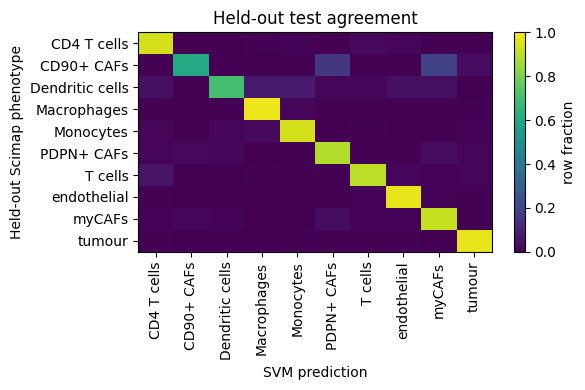

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()

for status, values in svm_adata.obs.groupby("svm_training_status", observed=True)["svm_max_probability"]:
    axes[0].hist(values.astype(float), bins=30, alpha=0.45, label=status)
axes[0].axvline(UNKNOWN_REFINEMENT_PROBABILITY_THRESHOLD, color="black", linestyle="--", linewidth=1)
axes[0].set_xlabel("Maximum SVM probability")
axes[0].set_ylabel("Cells")
axes[0].set_title("Prediction confidence")
axes[0].legend(frameon=False)

prediction_only_counts = (
    svm_adata.obs.loc[prediction_only, "svm_prediction"]
    .astype(str)
    .value_counts()
)
if prediction_only_counts.empty:
    axes[1].text(0.5, 0.5, "No prediction-only cells", ha="center", va="center")
    axes[1].set_axis_off()
else:
    prediction_only_counts.sort_values().plot.barh(ax=axes[1])
    axes[1].set_xlabel("Cells")
    axes[1].set_ylabel("SVM prediction")
    axes[1].set_title("Predictions for held-out Unknown cells")

known_disagreements = svm_adata.obs.loc[disagreement_mask].copy()
if known_disagreements.empty:
    axes[2].text(0.5, 0.5, "No known-label disagreements", ha="center", va="center")
    axes[2].set_axis_off()
else:
    axes[2].scatter(
        known_disagreements["svm_original_probability"],
        known_disagreements["svm_max_probability"],
        s=4,
        alpha=0.35,
    )
    axes[2].axhline(DISAGREEMENT_REFINEMENT_PROBABILITY_THRESHOLD, color="black", linestyle="--", linewidth=1)
    axes[2].plot([0, 1], [DISAGREEMENT_MARGIN_THRESHOLD, 1 + DISAGREEMENT_MARGIN_THRESHOLD], color="tab:red", linestyle="--", linewidth=1)
    axes[2].set_xlim(0, 1)
    axes[2].set_ylim(0, 1)
    axes[2].set_xlabel("P(original phenotype)")
    axes[2].set_ylabel("P(best SVM phenotype)")
    axes[2].set_title("Known-label disagreement confidence")

status_counts = svm_adata.obs["svm_refinement_status"].astype(str).value_counts()
status_counts.sort_values().plot.barh(ax=axes[3])
axes[3].set_xlabel("Cells")
axes[3].set_ylabel("Refinement status")
axes[3].set_title("Refinement decisions")

plt.tight_layout()
plt.show()
plt.close("all")

test_obs = svm_adata.obs.loc[test_names, [TARGET_KEY, "svm_prediction"]].copy()
test_crosstab = pd.crosstab(
    test_obs[TARGET_KEY].astype(str),
    test_obs["svm_prediction"].astype(str),
    normalize="index",
)
display(test_crosstab.round(3))

fig, ax = plt.subplots(figsize=(max(6, 0.45 * len(test_crosstab.columns)), max(4, 0.35 * len(test_crosstab.index))))
im = ax.imshow(test_crosstab.to_numpy(), aspect="auto", vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(np.arange(len(test_crosstab.columns)))
ax.set_xticklabels(test_crosstab.columns, rotation=90)
ax.set_yticks(np.arange(len(test_crosstab.index)))
ax.set_yticklabels(test_crosstab.index)
ax.set_xlabel("SVM prediction")
ax.set_ylabel("Held-out Scimap phenotype")
ax.set_title("Held-out test agreement")
fig.colorbar(im, ax=ax, label="row fraction")
plt.tight_layout()
plt.show()
plt.close("all")


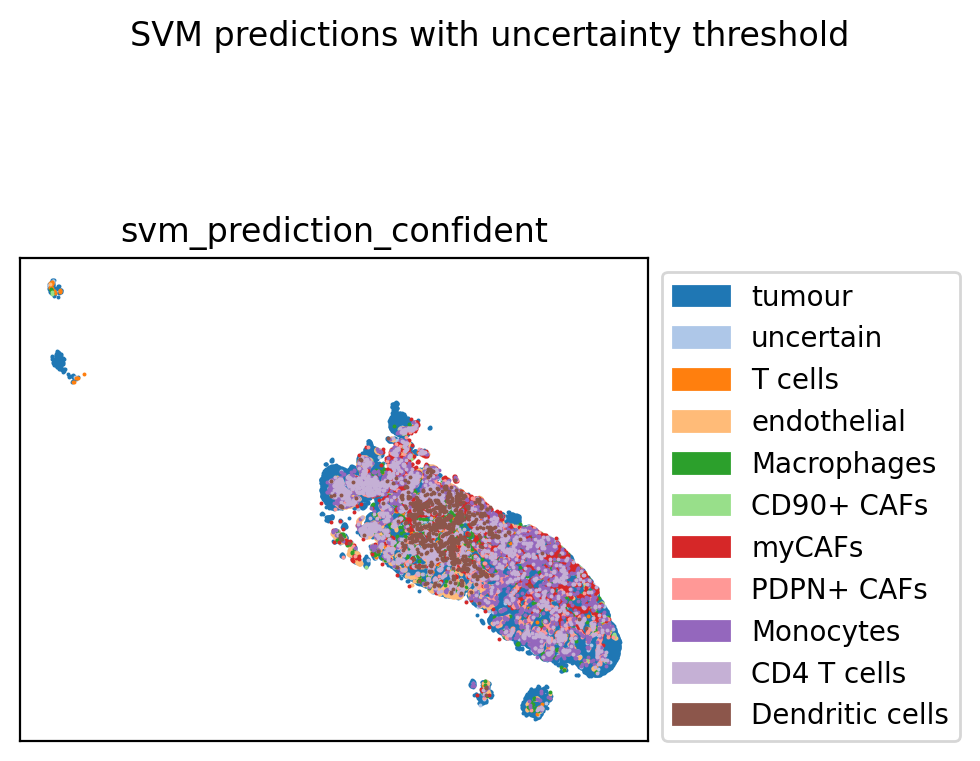

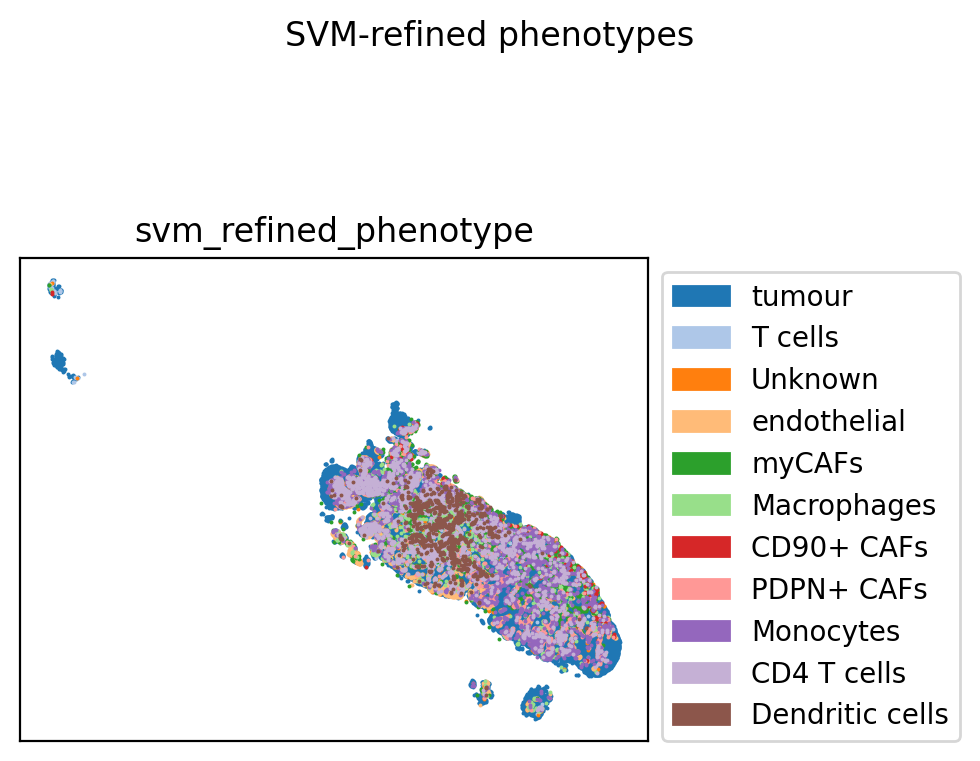

In [9]:
safe_spatial_scatter(
    svm_adata,
    "svm_prediction_confident",
    "SVM predictions with uncertainty threshold",
)
safe_spatial_scatter(
    svm_adata,
    "svm_refined_phenotype",
    "SVM-refined phenotypes",
)


## Overlay Disagreement Refinements On Original Image

Set `RUN_DISAGREEMENT_IMAGE_OVERLAY = True` to inspect high-confidence SVM disagreements on the original tissue image. The review subset includes applied disagreement refinements and, by default, high-confidence disagreement candidates that were only flagged for review.

Reviewing 1,426 disagreement cells


,n_cells
svm_disagreement_review_label,
tumour -> endothelial,194
tumour -> T cells,148
tumour -> CD4 T cells,147
tumour -> Monocytes,131
tumour -> PDPN+ CAFs,111
myCAFs -> PDPN+ CAFs,101
CD4 T cells -> T cells,56
tumour -> myCAFs,56
myCAFs -> CD90+ CAFs,46


/Users/shihongwu/SpatioEv/spatioev/pl/spatial.py:289: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


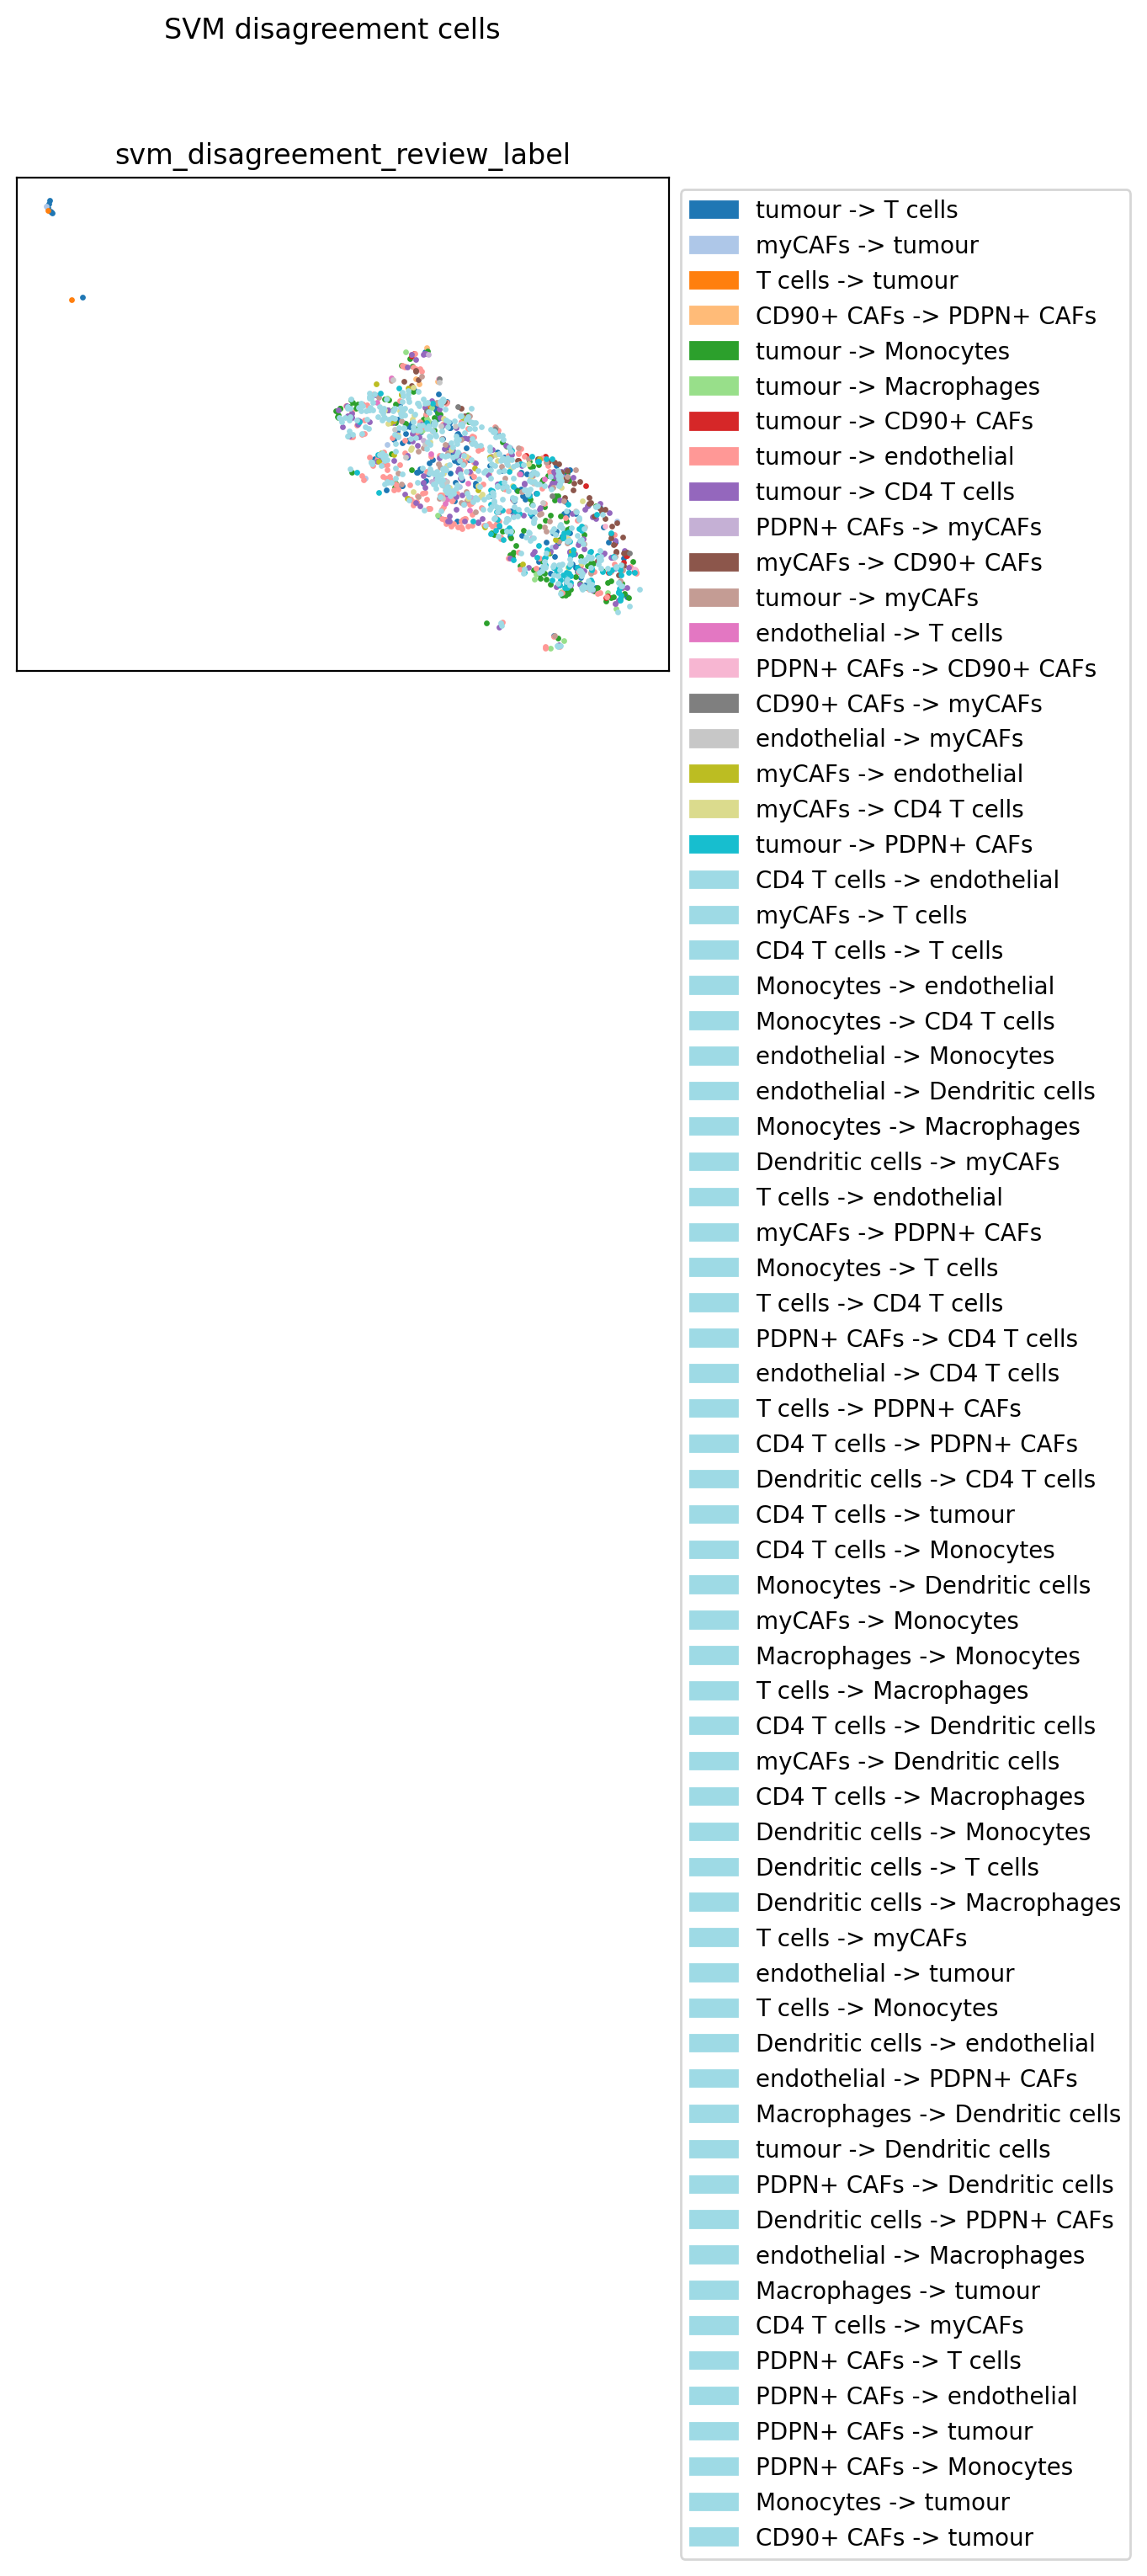

Running SCIMAP  2.3.5


/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/mpl_scatter_density/__init__.py:4: UserWarning:

pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.

/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html




Inspect clusters in napari. Close the viewer to continue.



In [10]:
REVIEW_REFINEMENT_STATUSES = [
    "refined_disagreement_from_prediction",
    "review_disagreement_high_confidence",
]
RUN_DISAGREEMENT_IMAGE_OVERLAY = True

review_mask = svm_adata.obs["svm_refinement_status"].isin(REVIEW_REFINEMENT_STATUSES)
svm_disagreement_review = svm_adata[review_mask.to_numpy()].copy()

if svm_disagreement_review.n_obs == 0:
    print("No disagreement-refined or high-confidence disagreement-review cells to overlay.")
else:
    svm_disagreement_review.obs["svm_disagreement_review_label"] = (
        svm_disagreement_review.obs[TARGET_KEY].astype(str)
        + " -> "
        + svm_disagreement_review.obs["svm_prediction"].astype(str)
    )
    print(f"Reviewing {svm_disagreement_review.n_obs:,} disagreement cells")
    show_counts(
        svm_disagreement_review.obs["svm_disagreement_review_label"],
        "svm_disagreement_review_label",
    )
    safe_spatial_scatter(
        svm_disagreement_review,
        "svm_disagreement_review_label",
        "SVM disagreement cells",
        size=6,
    )
    review_on_original_image(
        svm_disagreement_review,
        label="svm_disagreement_review_label",
        image_path=ORIGINAL_IMAGE_PATH,
        run=RUN_DISAGREEMENT_IMAGE_OVERLAY,
    )


## Overlay Final Refined Phenotypes On Original Image

Set `RUN_REFINED_PHENOTYPE_IMAGE_OVERLAY = True` to inspect the final `svm_refined_phenotype` labels on the original tissue image.


In [11]:
RUN_REFINED_PHENOTYPE_IMAGE_OVERLAY = False

if "svm_refined_phenotype" not in svm_adata.obs.columns:
    raise KeyError("Run the refinement cell before overlaying svm_refined_phenotype.")

show_counts(svm_adata.obs["svm_refined_phenotype"], "svm_refined_phenotype")
review_on_original_image(
    svm_adata,
    label="svm_refined_phenotype",
    image_path=ORIGINAL_IMAGE_PATH,
    run=RUN_REFINED_PHENOTYPE_IMAGE_OVERLAY,
)


,n_cells
svm_refined_phenotype,
tumour,25059
myCAFs,4729
endothelial,4432
Monocytes,2959
Unknown,2851
CD4 T cells,2596
T cells,2018
PDPN+ CAFs,1220
Macrophages,1218


Set run=True in this cell to open the original-image overlay viewer.


## Save Non-Artifact SVM Results

In [12]:
svm_result_cols = [
    TARGET_KEY,
    "svm_training_status",
    "svm_prediction",
    "svm_max_probability",
    "svm_prediction_confident",
    "svm_original_probability",
    "svm_probability_margin_over_original",
    "svm_refined_phenotype",
    "svm_refinement_status",
]
svm_adata.obs[svm_result_cols].to_csv(SVM_RESULT_PATH)
full_probability.to_csv(SVM_PROBABILITY_PATH)
report_df.to_csv(SVM_REPORT_PATH)
confusion_df.to_csv(SVM_CONFUSION_PATH)

print(f"Wrote {SVM_RESULT_PATH.relative_to(ROOT)}")
print(f"Wrote {SVM_PROBABILITY_PATH.relative_to(ROOT)}")
print(f"Wrote {SVM_REPORT_PATH.relative_to(ROOT)}")
print(f"Wrote {SVM_CONFUSION_PATH.relative_to(ROOT)}")


Wrote results/svm_phenotyping_results.csv
Wrote results/svm_phenotyping_probabilities.csv
Wrote results/svm_phenotyping_test_report.csv
Wrote results/svm_phenotyping_test_confusion_matrix.csv
